# Bloc 2 — « Comparison » : LR, SVM, XGBoost et stacking sous un protocole unique

**Projet Applied ML — Albert School × Mines Paris-PSL.** Suite de
[`01_eda.ipynb`](01_eda.ipynb).

Consigne : *comparer Logistic Regression, SVM, XGBoost et stacking sous un
protocole cohérent, et quantifier l'incertitude avant de nommer un gagnant.*

Ce notebook **n'entraîne rien et ne calcule aucune métrique** : il relit les
résultats produits par `make train` puis `make holdout`, et les commente. Toute
la logique vit dans `src/` (`features`, `models`, `evaluate`, `train`, `holdout`,
`report`). Le protocole et la règle de décision, pré-enregistrés avant la CV
complète et avant le holdout, sont dans
[`reports/bloc2_decisions.md`](../reports/bloc2_decisions.md). Le rapport
généré est [`reports/model_comparison.md`](../reports/model_comparison.md).

Tout chiffre affiché ici provient d'une variable calculée.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd().parent / "src"))
import evaluate as E
import features as F
import models as M
import report as R

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

cfg = F.load_config()
res = R.load_results(cfg)
ks = cfg["metrics"]["ks"]
names = E.metric_names(ks)
rank_names = ["pr_auc", "roc_auc"] + [n for n in names if n.startswith("recall")]
prec_names = [n for n in names if n.startswith("precision")]
ref = cfg["features"]["reference_set"]
sel, dec = res["selection"], res["decision"]
retained = sel["retained_key"]
print(f"Résultats chargés : {len(res['cv_summary'])} modèles en CV, "
      f"{res['holdout']['model'].nunique()} évalués sur le holdout ({dec['mode']}).")

Résultats chargés : 10 modèles en CV, 11 évalués sur le holdout (holdout).


## 1. Protocole

Split temporel (EDA §4) : train = 1994–1995, holdout = 1996. Dans le train, une
CV **forward-chaining** (`TimeSeriesSplit`) : chaque fold de validation est
postérieur à tout son train. On vérifie la taille et le nombre de fraudes de
chaque fold, pour s'assurer qu'une PR-AUC y est estimable.

In [2]:
split = dec["holdout_split"]
print(f"Train : {split['n_train']:,} sinistres, {split['n_fraud_train']} fraudes "
      f"(PolicyNumber {split['train_policy_min']}–{split['train_policy_max']})")
print(f"Holdout : {split['n_test']:,} sinistres, {split['n_fraud_test']} fraudes "
      f"(PolicyNumber {split['test_policy_min']}–{split['test_policy_max']})")
res["fold_info"]

Train : 11,337 sinistres, 710 fraudes (PolicyNumber 1–11337)
Holdout : 4,083 sinistres, 213 fraudes (PolicyNumber 11338–15420)


,fold,n_train,n_fraud_train,n_val,n_fraud_val,train_policy_max,val_policy_min,val_policy_max
0,1,1892,127,1889,122,1892,1893,3781
1,2,3781,249,1889,115,3781,3782,5670
2,3,5670,364,1889,133,5670,5671,7559
3,4,7559,497,1889,104,7559,7560,9448
4,5,9448,601,1889,109,9448,9449,11337


## 2. Validation croisée temporelle (train seul)

Même prétraitement, même splitter, même budget de tuning pour LR, SVM et
XGBoost ; le stacking réutilise leurs hyperparamètres retenus. Moyenne ±
écart-type sur les folds. Les baselines servent de repère : le prior donne le
niveau du hasard (PR-AUC = prévalence), la baseline métier ce que donnent les
deux signaux les plus forts, `Fault` × `BasePolicy`.

In [3]:
R.cv_frame(res, cfg, rank_names)

,PR-AUC,ROC-AUC,rappel@5 %,rappel@10 %,rappel@20 %
Modèle,,,,,
Régression logistique (fs_basepolicy),0.132 ± 0.021,0.774 ± 0.032,7.7 % ± 5.6 %,18.0 % ± 7.5 %,45.9 % ± 10.7 %
SVM RBF (fs_basepolicy),0.141 ± 0.032,0.720 ± 0.067,12.1 % ± 2.1 %,23.4 % ± 6.5 %,41.7 % ± 10.4 %
XGBoost (fs_basepolicy),0.111 ± 0.043,0.688 ± 0.080,5.6 % ± 5.2 %,12.0 % ± 9.4 %,29.8 % ± 17.9 %
Stacking (fs_basepolicy),0.124 ± 0.038,0.736 ± 0.062,6.0 % ± 5.9 %,13.0 % ± 9.8 %,33.8 % ± 19.5 %
Régression logistique (fs_policytype),0.134 ± 0.018,0.778 ± 0.032,8.3 % ± 4.8 %,19.0 % ± 7.3 %,48.4 % ± 9.0 %
SVM RBF (fs_policytype),0.141 ± 0.022,0.727 ± 0.053,14.0 % ± 2.6 %,23.7 % ± 6.2 %,40.2 % ± 7.6 %
XGBoost (fs_policytype),0.113 ± 0.044,0.688 ± 0.081,6.1 % ± 5.0 %,12.3 % ± 9.0 %,30.2 % ± 18.0 %
Stacking (fs_policytype),0.125 ± 0.038,0.738 ± 0.062,6.2 % ± 5.8 %,13.5 % ± 9.4 %,34.7 % ± 18.7 %
Baseline prior,0.062 ± 0.006,0.500 ± 0.000,5.0 % ± 0.0 %,10.0 % ± 0.0 %,20.0 % ± 0.0 %


In [4]:
R.cv_frame(res, cfg, prec_names)

,précision@5 %,précision@10 %,précision@20 %
Modèle,,,
Régression logistique (fs_basepolicy),9.1 % ± 6.3 %,10.9 % ± 4.2 %,14.1 % ± 3.2 %
SVM RBF (fs_basepolicy),14.7 % ± 1.7 %,14.3 % ± 3.4 %,12.8 % ± 2.9 %
XGBoost (fs_basepolicy),6.5 % ± 5.8 %,7.1 % ± 5.2 %,9.0 % ± 5.0 %
Stacking (fs_basepolicy),6.9 % ± 6.6 %,7.7 % ± 5.5 %,10.3 % ± 5.8 %
Régression logistique (fs_policytype),9.9 % ± 5.3 %,11.5 % ± 4.1 %,14.9 % ± 2.9 %
SVM RBF (fs_policytype),17.1 % ± 2.6 %,14.5 % ± 3.3 %,12.4 % ± 2.5 %
XGBoost (fs_policytype),7.2 % ± 5.5 %,7.3 % ± 5.0 %,9.1 % ± 5.0 %
Stacking (fs_policytype),7.2 % ± 6.4 %,8.0 % ± 5.2 %,10.5 % ± 5.5 %
Baseline prior,6.2 % ± 0.6 %,6.2 % ± 0.6 %,6.2 % ± 0.6 %


Les scores par fold montrent deux choses que la moyenne cache : leur
**dispersion** (d'où des intervalles larges) et leur **appariement** (les
modèles montent et descendent ensemble d'un fold à l'autre). C'est pourquoi la
règle compare des **différences appariées**, et non des moyennes.

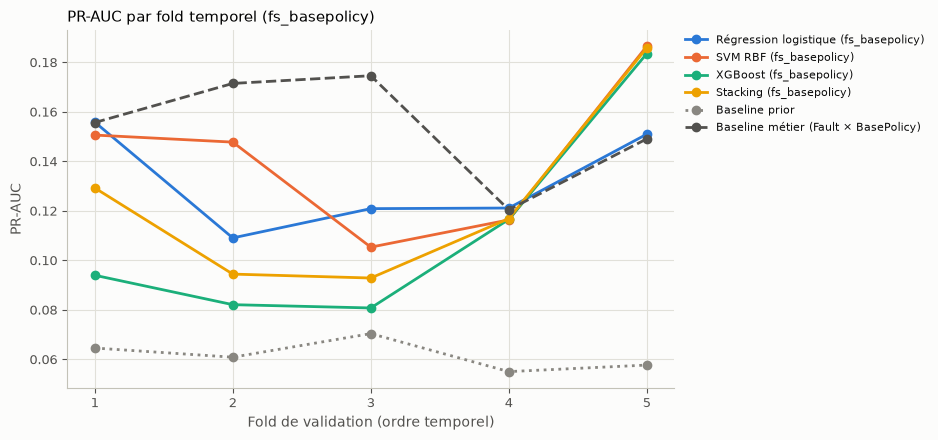

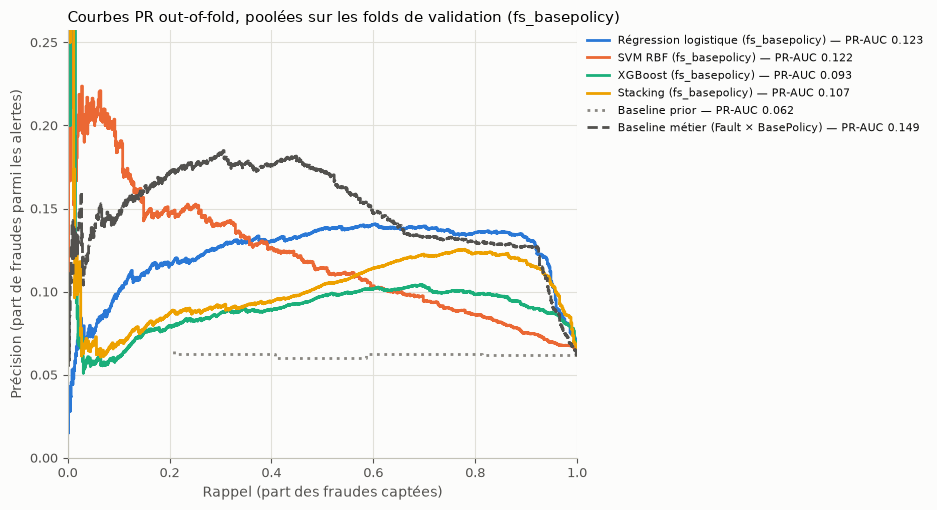

In [5]:
keys = [M.model_key(f, ref) for f in M.MODEL_FAMILIES] + M.BASELINES
fig = E.plot_fold_scores(res["cv_folds"], "pr_auc", keys, f"PR-AUC par fold temporel ({ref})")
plt.show()
oof = res["oof_scores"]
fig = E.plot_pr_curves(oof["y"], {k: oof[k] for k in keys},
                       f"Courbes PR out-of-fold, poolées sur les folds de validation ({ref})")
plt.show()

## 3. Règle de décision, étapes 1, 2 et 2 bis (CV uniquement)

1. Candidat : meilleure PR-AUC moyenne en CV sur le feature set de référence.
2. Pour chaque modèle plus simple (LR < SVM < XGBoost < stacking) : IC à 95 % de
   la différence appariée par fold, avec une variance **corrigée par Nadeau-Bengio**
   (les trains des folds se recouvrent, le t naïf serait trop étroit et
   favoriserait le modèle complexe). On retient le plus simple des modèles dont
   l'IC contient 0.
3. Feature set : `fs_policytype` seulement si son IC exclut 0 par le haut.

Cette sélection est écrite dans `cv_selection.json` **avant** que le holdout ne
soit lu.

In [6]:
display(R.selection_frame(res))
means = pd.Series(sel["cv_means"], name="PR-AUC moyenne CV").map(R.num)
display(means.to_frame())
display(Markdown(
    f"**Meilleur en CV : {E.model_label(M.model_key(sel['best_cv'], ref))}. "
    f"Retenu par la règle : {E.model_label(retained)}.**"))

,Comparaison,Différence moyenne,IC Nadeau-Bengio,IC t naïf (info)
0,SVM RBF (fs_basepolicy) − Régression logistique (fs_basepolicy),+0.0097,[-0.0474 ; +0.0669],[-0.0218 ; +0.0413]
1,Régression logistique (fs_policytype) − Régression logistique (fs_basepolicy),+0.0020,[-0.0094 ; +0.0133],[-0.0043 ; +0.0083]


,PR-AUC moyenne CV
logreg,0.132
svm,0.141
xgb,0.111
stacking,0.124


**Meilleur en CV : SVM RBF (fs_basepolicy). Retenu par la règle : Régression logistique (fs_basepolicy).**

## 4. Holdout 1996 — évalué une seule fois

Chaque pipeline, refitté sur tout 1994–1995, score 1996. L'incertitude vient
d'un **bootstrap stratifié apparié** : on rééchantillonne fraudes et
non-fraudes séparément, avec les mêmes indices pour tous les modèles. Les IC
sont des percentiles à 95 %.

In [7]:
R.holdout_frame(res, cfg, rank_names)

,PR-AUC,ROC-AUC,rappel@5 %,rappel@10 %,rappel@20 %
Modèle,,,,,
Régression logistique (fs_basepolicy),0.100 [0.089 ; 0.121],0.746 [0.722 ; 0.771],9.4 % [6.1 ; 13.6] %,16.0 % [11.7 ; 21.6] %,34.3 % [28.6 ; 41.3] %
SVM RBF (fs_basepolicy),0.123 [0.104 ; 0.160],0.740 [0.707 ; 0.770],15.0 % [10.8 ; 19.7] %,23.0 % [17.8 ; 28.6] %,43.2 % [36.6 ; 50.7] %
XGBoost (fs_basepolicy),0.128 [0.103 ; 0.166],0.751 [0.729 ; 0.773],10.3 % [6.1 ; 14.1] %,19.7 % [15.0 ; 25.4] %,32.9 % [26.3 ; 39.0] %
Stacking (fs_basepolicy),0.129 [0.104 ; 0.166],0.753 [0.730 ; 0.775],9.9 % [6.6 ; 14.1] %,18.3 % [14.1 ; 23.9] %,33.8 % [28.2 ; 39.9] %
Régression logistique (fs_policytype),0.103 [0.092 ; 0.124],0.755 [0.730 ; 0.778],8.5 % [4.7 ; 12.2] %,18.3 % [13.6 ; 23.9] %,37.6 % [31.5 ; 44.6] %
SVM RBF (fs_policytype),0.101 [0.086 ; 0.131],0.696 [0.664 ; 0.727],9.4 % [5.6 ; 13.1] %,17.4 % [12.7 ; 22.5] %,36.6 % [30.5 ; 43.2] %
XGBoost (fs_policytype),0.133 [0.107 ; 0.171],0.757 [0.735 ; 0.780],11.3 % [7.5 ; 15.5] %,22.5 % [16.9 ; 28.6] %,37.1 % [31.0 ; 43.2] %
Stacking (fs_policytype),0.132 [0.108 ; 0.170],0.760 [0.737 ; 0.783],11.3 % [7.5 ; 16.0] %,21.1 % [16.4 ; 27.2] %,37.6 % [31.5 ; 43.7] %
Baseline prior,0.052 [0.052 ; 0.052],0.500 [0.500 ; 0.500],5.0 % [5.0 ; 5.0] %,10.0 % [10.0 ; 10.0] %,20.0 % [20.0 ; 20.0] %


In [8]:
R.holdout_frame(res, cfg, prec_names)

,précision@5 %,précision@10 %,précision@20 %
Modèle,,,
Régression logistique (fs_basepolicy),9.8 % [6.3 ; 14.1] %,8.3 % [6.1 ; 11.2] %,8.9 % [7.5 ; 10.8] %
SVM RBF (fs_basepolicy),15.6 % [11.2 ; 20.5] %,12.0 % [9.3 ; 14.9] %,11.3 % [9.5 ; 13.2] %
XGBoost (fs_basepolicy),10.7 % [6.3 ; 14.6] %,10.3 % [7.8 ; 13.2] %,8.6 % [6.9 ; 10.2] %
Stacking (fs_basepolicy),10.2 % [6.8 ; 14.6] %,9.5 % [7.3 ; 12.5] %,8.8 % [7.3 ; 10.4] %
Régression logistique (fs_policytype),8.8 % [4.9 ; 12.7] %,9.5 % [7.1 ; 12.5] %,9.8 % [8.2 ; 11.6] %
SVM RBF (fs_policytype),9.8 % [5.9 ; 13.7] %,9.0 % [6.6 ; 11.7] %,9.5 % [8.0 ; 11.3] %
XGBoost (fs_policytype),11.7 % [7.8 ; 16.1] %,11.7 % [8.8 ; 14.9] %,9.7 % [8.1 ; 11.3] %
Stacking (fs_policytype),11.7 % [7.8 ; 16.6] %,11.0 % [8.6 ; 14.2] %,9.8 % [8.2 ; 11.4] %
Baseline prior,5.2 % [5.2 ; 5.2] %,5.2 % [5.2 ; 5.2] %,5.2 % [5.2 ; 5.2] %


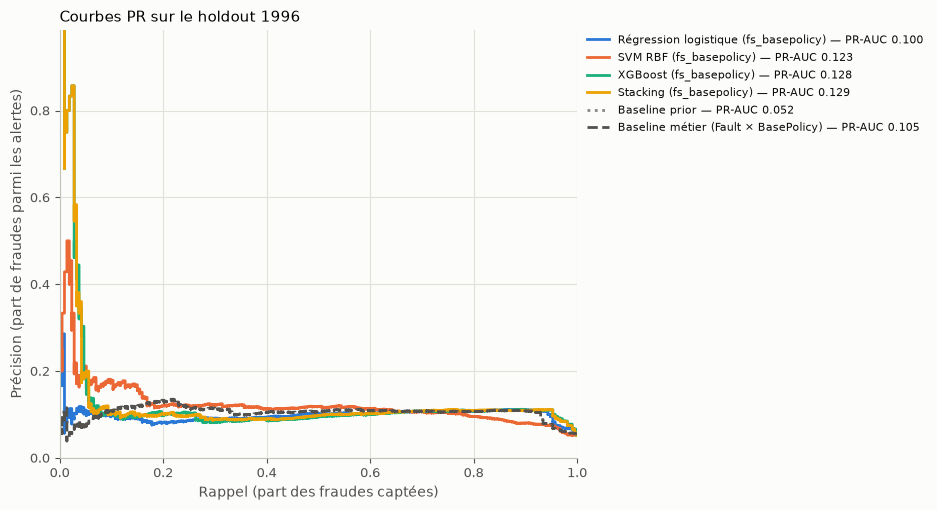

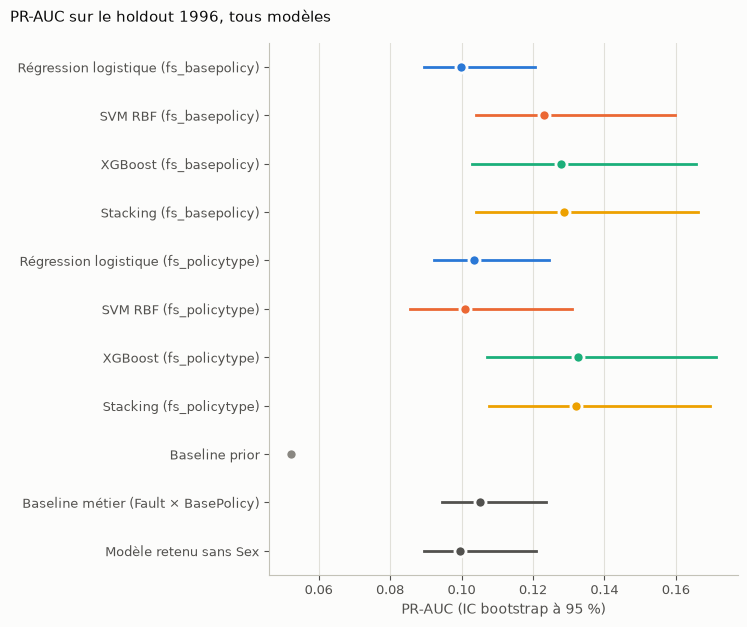

In [9]:
hs = res["holdout_scores"]
curve_keys = keys if retained in keys else [retained] + keys
fig = E.plot_pr_curves(hs["y"], {k: hs[k] for k in curve_keys}, "Courbes PR sur le holdout 1996")
plt.show()
ap = res["holdout"].query("metric == 'pr_auc'").rename(columns={"model": "key"})
order = R.model_order(cfg) + [R.ABLATION]
ap = ap.set_index("key").loc[order].reset_index()
fig = E.plot_intervals(ap, "PR-AUC (IC bootstrap à 95 %)", "PR-AUC sur le holdout 1996, tous modèles")
plt.show()

## 5. Étapes 3 et 4 : battre les baselines, sans re-sélectionner

Le modèle retenu doit battre **chaque** baseline : IC bootstrap de la
différence de PR-AUC entièrement au-dessus de 0. Si un autre modèle fait
significativement mieux sur 1996, on le rapporte, mais on ne change pas de
modèle : re-sélectionner sur le test serait du test-snooping.

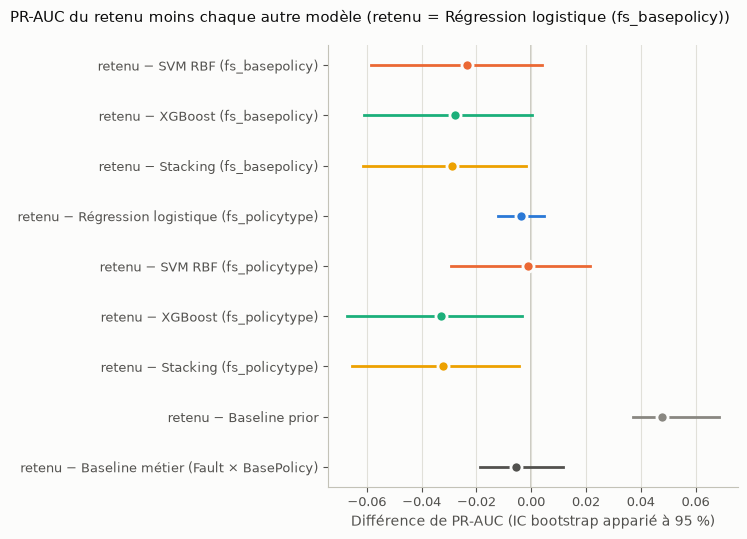

- Baseline prior : différence +0.0477 [+0.0373 ; +0.0685] → battue
- Baseline métier (Fault × BasePolicy) : différence -0.0055 [-0.0188 ; +0.0116] → **gain non démontré**
- Contradiction CV / holdout : Stacking (fs_basepolicy), XGBoost (fs_policytype), Stacking (fs_policytype) (pas de re-sélection).

In [10]:
mine = res["diffs"].query("comparison == 'retenu_vs_autres'").copy()
mine["key"], mine["point"] = mine["model_b"], mine["diff"]
mine["label"] = ["retenu − " + E.model_label(k) for k in mine["model_b"]]
fig = E.plot_intervals(mine, "Différence de PR-AUC (IC bootstrap apparié à 95 %)",
                       f"PR-AUC du retenu moins chaque autre modèle (retenu = {E.model_label(retained)})",
                       reference=0.0)
plt.show()
checks = dec["holdout_checks"]
lines = []
for b, ok in checks["beats_baselines"].items():
    row = mine.set_index("model_b").loc[b]
    status = "battue" if ok else "**gain non démontré**"
    lines.append(f"- {E.model_label(b)} : différence {R.signed(row['diff'])} "
                 f"{R.ci(row['ci_low'], row['ci_high'], sign=True)} → {status}")
contra = ", ".join(E.model_label(k) for k in checks["contradicted_by"]) or "aucune"
lines.append(f"- Contradiction CV / holdout : {contra} (pas de re-sélection).")
display(Markdown("\n".join(lines)))

## 6. Ablations (chiffres seulement)

- `fs_policytype` vs `fs_basepolicy`, famille par famille, sur le holdout.
- `ablation_no_sex` : le modèle retenu sans `Sex`, avec les mêmes
  hyperparamètres. L'interprétation (équité, slices sensibles, EDA §5) revient
  au bloc 4.

In [11]:
abl = res["diffs"].query("comparison != 'retenu_vs_autres'").copy()
abl["Comparaison"] = [f"{E.model_label(a)} − {E.model_label(b)}"
                      for a, b in zip(abl["model_a"], abl["model_b"])]
abl["Différence"] = abl["diff"].map(R.signed)
abl["IC 95 %"] = [R.ci(lo, hi, sign=True) for lo, hi in zip(abl["ci_low"], abl["ci_high"])]
abl[["Comparaison", "Différence", "IC 95 %", "verdict"]]

,Comparaison,Différence,IC 95 %,verdict
9,Régression logistique (fs_policytype) − Régression logistique (fs_basepolicy),+0.0036,[-0.0048 ; +0.0122],non significatif
10,SVM RBF (fs_policytype) − SVM RBF (fs_basepolicy),-0.0221,[-0.0391 ; -0.0084],b > a
11,XGBoost (fs_policytype) − XGBoost (fs_basepolicy),+0.0049,[+0.0004 ; +0.0106],a > b
12,Stacking (fs_policytype) − Stacking (fs_basepolicy),+0.0034,[-0.0022 ; +0.0086],non significatif
13,Modèle retenu sans Sex − Régression logistique (fs_basepolicy),-0.0001,[-0.0028 ; +0.0025],non significatif


## 7. Conclusion (générée)

Le texte ci-dessous est construit à partir des variables : aucun chiffre n'est
saisi à la main.

In [12]:
ret_ap = res["holdout"].set_index(["model", "metric"]).loc[(retained, "pr_auc")]
best_key = M.model_key(sel["best_cv"], ref)
cv_best = res["cv_summary"].set_index("model").loc[best_key]
txt = f'''
- **Sélection (CV du train seule)** : meilleure PR-AUC moyenne pour
  {E.model_label(best_key)} ({R.num(cv_best["pr_auc_mean"])} ± {R.num(cv_best["pr_auc_std"])}).
  Règle de simplicité → **{E.model_label(retained)}**.
- **Holdout 1996** : PR-AUC du retenu {R.num(ret_ap["point"])} {R.ci(ret_ap["ci_low"], ret_ap["ci_high"])}.
- **Baselines** : {"toutes battues" if checks["beats_all_baselines"] else "pas toutes battues — voir §5 : le gain du ML n'est pas démontré face à " + ", ".join(E.model_label(b) for b, ok in checks["beats_baselines"].items() if not ok)}.
- **Pour le bloc 4** : scores bruts dans `reports/predictions/`, pipeline dans
  `models/{retained}.joblib` ; calibration, seuil opérationnel, slices et SHAP restent à traiter.
'''
display(Markdown(txt))


- **Sélection (CV du train seule)** : meilleure PR-AUC moyenne pour
  SVM RBF (fs_basepolicy) (0.141 ± 0.032).
  Règle de simplicité → **Régression logistique (fs_basepolicy)**.
- **Holdout 1996** : PR-AUC du retenu 0.100 [0.089 ; 0.121].
- **Baselines** : pas toutes battues — voir §5 : le gain du ML n'est pas démontré face à Baseline métier (Fault × BasePolicy).
- **Pour le bloc 4** : scores bruts dans `reports/predictions/`, pipeline dans
  `models/logreg__fs_basepolicy.joblib` ; calibration, seuil opérationnel, slices et SHAP restent à traiter.
